# Land-Use Classification from Multispectral Satellite Imagery

## 1 — Setup, Data Preparation, Data Processing, EDA and Reproducible Split


We have two local copies of the dataset:

- `datasets/EuroSAT` — RGB JPGs (3 visible bands).
- `datasets/EuroSATallBands` — 13-band Sentinel-2 GeoTIFFs.




In [1]:
# Imports
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio          # reads 13-band GeoTIFFs
from PIL import Image    # reads RGB JPGs
from sklearn.model_selection import train_test_split

# ---- Configuration (single source of truth for the whole project) ----
RGB_ROOT = Path("datasets/EuroSAT_RGB")           # RGB JPGs
MS_ROOT  = Path("datasets/EuroSAT_MS")   # 13-band GeoTIFFs

RANDOM_SEED = 42
TEST_FRACTION = 0.20

CLASS_NAMES = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway", "Industrial",
    "Pasture", "PermanentCrop", "Residential", "River", "SeaLake",
]

# Sentinel-2 band order in the EuroSAT GeoTIFFs (13 bands).
BAND_NAMES = [
    "B01_Aerosol", "B02_Blue", "B03_Green", "B04_Red", "B05_RedEdge1",
    "B06_RedEdge2", "B07_RedEdge3", "B08_NIR", "B08A_RedEdge4",
    "B09_WaterVapour", "B10_Cirrus", "B11_SWIR1", "B12_SWIR2",
]

np.random.seed(RANDOM_SEED)

# print(f"RGB root exists: {RGB_ROOT.exists()}  ->  {RGB_ROOT.resolve()}")
print(f"MS  root exists: {MS_ROOT.exists()}  ->  {MS_ROOT.resolve()}")
print(f"Seed: {RANDOM_SEED} | Test fraction: {TEST_FRACTION} | Classes: {len(CLASS_NAMES)}")

MS  root exists: True  ->  /Users/anikghosh/Desktop/test/Satellite Image Classification/datasets/EuroSAT_MS
Seed: 42 | Test fraction: 0.2 | Classes: 10


Before indexing thousands of files, confirm both dataset variants exist, expose the
same 10 class folders, and contain the file types we expect (`.jpg` for RGB, `.tif`
for multispectral). This catches path typos and incomplete downloads early.

In [2]:
def inspect_root(root: Path, expected_ext: str):
    """Print per-class folder presence and file counts for one dataset variant."""
    if not root.exists():
        print(f"  MISSING: {root}")
        return

    subfolders = sorted(p.name for p in root.iterdir() if p.is_dir())
    print(f"  Class folders found ({len(subfolders)}): {subfolders}")

    # Confirm expected extension on a sample folder
    sample_class = subfolders[0]
    exts = {p.suffix.lower() for p in (root / sample_class).iterdir() if p.is_file()}
    print(f"  Extensions in '{sample_class}': {exts}  (expected '{expected_ext}')")

print("RGB variant:")
inspect_root(RGB_ROOT, ".jpg")
print("\nMultispectral variant:")
inspect_root(MS_ROOT, ".tif")

# Sanity check: both variants should expose exactly our 10 expected classes
rgb_classes = sorted(p.name for p in RGB_ROOT.iterdir() if p.is_dir()) if RGB_ROOT.exists() else []
ms_classes  = sorted(p.name for p in MS_ROOT.iterdir() if p.is_dir()) if MS_ROOT.exists() else []
print("\nClass folders match across variants:", rgb_classes == ms_classes)
print("Match expected CLASS_NAMES:", sorted(rgb_classes) == sorted(CLASS_NAMES))

RGB variant:
  Class folders found (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
  Extensions in 'AnnualCrop': {'.jpg'}  (expected '.jpg')

Multispectral variant:
  Class folders found (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
  Extensions in 'AnnualCrop': {'.tif'}  (expected '.tif')

Class folders match across variants: True
Match expected CLASS_NAMES: True


### Build a unified file index

We create a single dataframe keyed by `patch_id`, holding the RGB path, the
multispectral path, and the class label for every patch. Both downstream milestones
(RGB baseline, multispectral model) load from this one table, which keeps the two
variants aligned by construction.

In [3]:
def build_index(rgb_root: Path, ms_root: Path) -> pd.DataFrame:
    """One row per patch: patch_id, class_label, rgb_path, ms_path."""
    rows = []
    for class_name in CLASS_NAMES:
        rgb_dir = rgb_root / class_name
        ms_dir  = ms_root / class_name

        # Map patch stem -> full path for each variant, so we can align them
        rgb_files = {p.stem: p for p in rgb_dir.glob("*.jpg")} if rgb_dir.exists() else {}
        ms_files  = {p.stem: p for p in ms_dir.glob("*.tif")}  if ms_dir.exists()  else {}

        # Keep patches present in BOTH variants (intersection of stems)
        common_ids = sorted(set(rgb_files) & set(ms_files))
        for patch_id in common_ids:
            rows.append({
                "patch_id": patch_id,
                "class_label": class_name,
                "rgb_path": str(rgb_files[patch_id]),
                "ms_path":  str(ms_files[patch_id]),
            })
    return pd.DataFrame(rows)

index_df = build_index(RGB_ROOT, MS_ROOT)
print(f"Total aligned patches: {len(index_df)}")
index_df.head()

Total aligned patches: 27000


,patch_id,class_label,rgb_path,ms_path
0,AnnualCrop_1,AnnualCrop,datasets/EuroSAT_RGB/AnnualCrop/AnnualCrop_1.jpg,datasets/EuroSAT_MS/AnnualCrop/AnnualCrop_1.tif
1,AnnualCrop_10,AnnualCrop,datasets/EuroSAT_RGB/AnnualCrop/AnnualCrop_10.jpg,datasets/EuroSAT_MS/AnnualCrop/AnnualCrop_10.tif
2,AnnualCrop_100,AnnualCrop,datasets/EuroSAT_RGB/AnnualCrop/AnnualCrop_100...,datasets/EuroSAT_MS/AnnualCrop/AnnualCrop_100.tif
3,AnnualCrop_1000,AnnualCrop,datasets/EuroSAT_RGB/AnnualCrop/AnnualCrop_100...,datasets/EuroSAT_MS/AnnualCrop/AnnualCrop_1000...
4,AnnualCrop_1001,AnnualCrop,datasets/EuroSAT_RGB/AnnualCrop/AnnualCrop_100...,datasets/EuroSAT_MS/AnnualCrop/AnnualCrop_1001...


### Check for number of samples for each class
This is to check for any severe class imbalance

In [6]:
class_counts = index_df["class_label"].value_counts().reindex(CLASS_NAMES)
print(class_counts)
print(f"\nTotal: {class_counts.sum()}  |  min: {class_counts.min()}  |  max: {class_counts.max()}")

class_label
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Highway                 2500
Industrial              2500
Pasture                 2000
PermanentCrop           2500
Residential             3000
River                   2500
SeaLake                 3000
Name: count, dtype: int64

Total: 27000  |  min: 2000  |  max: 3000


### EDA — inspect a single sample (shape, dtype, value range)

We load the RGB and 13-band versions of the *same* patch to understand exactly what
each loader returns before processing at scale. The key thing to surface here is the
**value-range difference**: RGB JPGs are 8-bit (0–255), while the GeoTIFF bands are
16-bit Sentinel-2 reflectance (much larger integer range). The two pipelines will
therefore need **different normalisation** — an important preprocessing decision.

In [7]:
sample = index_df.iloc[0]
print(f"Sample patch: {sample.patch_id} ({sample.class_label})\n")

# --- RGB ---
rgb = np.array(Image.open(sample.rgb_path))
print("RGB JPG")
print(f"  shape: {rgb.shape}  (H, W, channels — channels-last)")
print(f"  dtype: {rgb.dtype}")
print(f"  min/max: {rgb.min()} / {rgb.max()}")

# --- Multispectral ---
with rasterio.open(sample.ms_path) as src:
    ms = src.read()  # rasterio returns (bands, H, W) — channels-FIRST
print("\nMultispectral GeoTIFF")
print(f"  shape: {ms.shape}  (bands, H, W — channels-first)")
print(f"  dtype: {ms.dtype}")
print(f"  min/max: {ms.min()} / {ms.max()}")
print(f"  band count: {ms.shape[0]} (expected 13)")

Sample patch: AnnualCrop_1 (AnnualCrop)

RGB JPG
  shape: (64, 64, 3)  (H, W, channels — channels-last)
  dtype: uint8
  min/max: 82 / 204

Multispectral GeoTIFF
  shape: (13, 64, 64)  (bands, H, W — channels-first)
  dtype: uint16
  min/max: 9 / 3490
  band count: 13 (expected 13)


**Note the axis-order mismatch:** RGB loads channels-*last* `(64, 64, 3)`, rasterio
loads channels-*first* `(13, 64, 64)`. We need to either convert it to (H,W,channels) or (channels,H,W)

We sample a few hundred multispectral patches and compute per-band statistics. This
shows how the 13 bands differ in magnitude and flags any near-empty band. 

In [8]:
def sample_band_stats(df: pd.DataFrame, n: int = 300, seed: int = RANDOM_SEED) -> pd.DataFrame:
    """Mean/std/min/max per band over a random sample of patches."""
    sample_df = df.sample(n=min(n, len(df)), random_state=seed)

    # Accumulate per-band pixel values across the sample
    per_band = [[] for _ in range(len(BAND_NAMES))]
    for ms_path in sample_df["ms_path"]:
        with rasterio.open(ms_path) as src:
            arr = src.read()  # (13, 64, 64)
        for b in range(arr.shape[0]):
            per_band[b].append(arr[b].ravel())

    stats = []
    for b, name in enumerate(BAND_NAMES):
        vals = np.concatenate(per_band[b])
        stats.append({
            "band": name,
            "mean": round(float(vals.mean()), 1),
            "std":  round(float(vals.std()), 1),
            "min":  int(vals.min()),
            "max":  int(vals.max()),
        })
    return pd.DataFrame(stats)

band_stats = sample_band_stats(index_df, n=300)
band_stats

,band,mean,std,min,max
0,B01_Aerosol,1367.3,255.4,907,4475
1,B02_Blue,1131.8,347.9,248,18178
2,B03_Green,1057.7,403.4,132,19711
3,B04_Red,959.5,591.8,163,22616
4,B05_RedEdge1,1209.7,549.0,189,8520
5,B06_RedEdge2,1968.7,832.2,158,10026
6,B07_RedEdge3,2317.1,1040.2,135,10925
7,B08_NIR,2240.6,1073.5,102,22795
8,B08A_RedEdge4,707.3,399.1,50,2752
9,B09_WaterVapour,12.2,5.1,3,72


### Visual EDA — one RGB sample per class

A quick visual confirmation that labels look sane: Forest should be green, SeaLake
blue, Residential built-up, and so on.

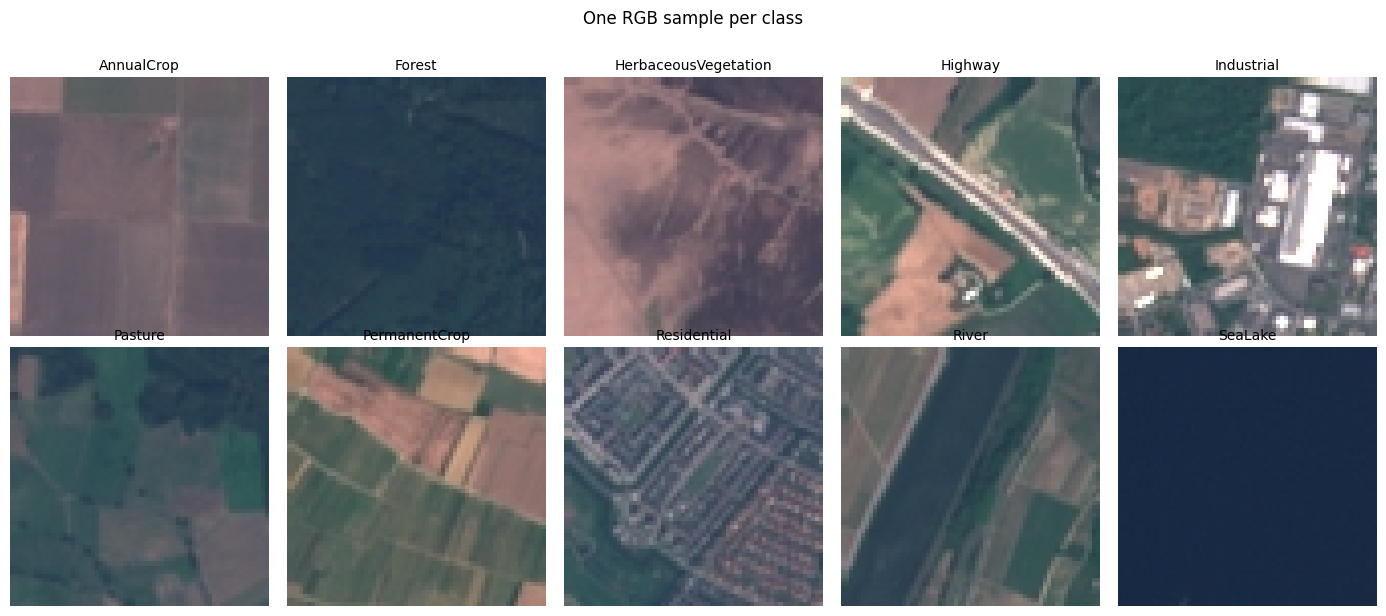

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, class_name in zip(axes.ravel(), CLASS_NAMES):
    row = index_df[index_df.class_label == class_name].iloc[0]
    ax.imshow(np.array(Image.open(row.rgb_path)))
    ax.set_title(class_name, fontsize=10)
    ax.axis("off")
plt.suptitle("One RGB sample per class", y=1.02)
plt.tight_layout()
plt.show()

### Visual EDA — all 13 bands of a single patch

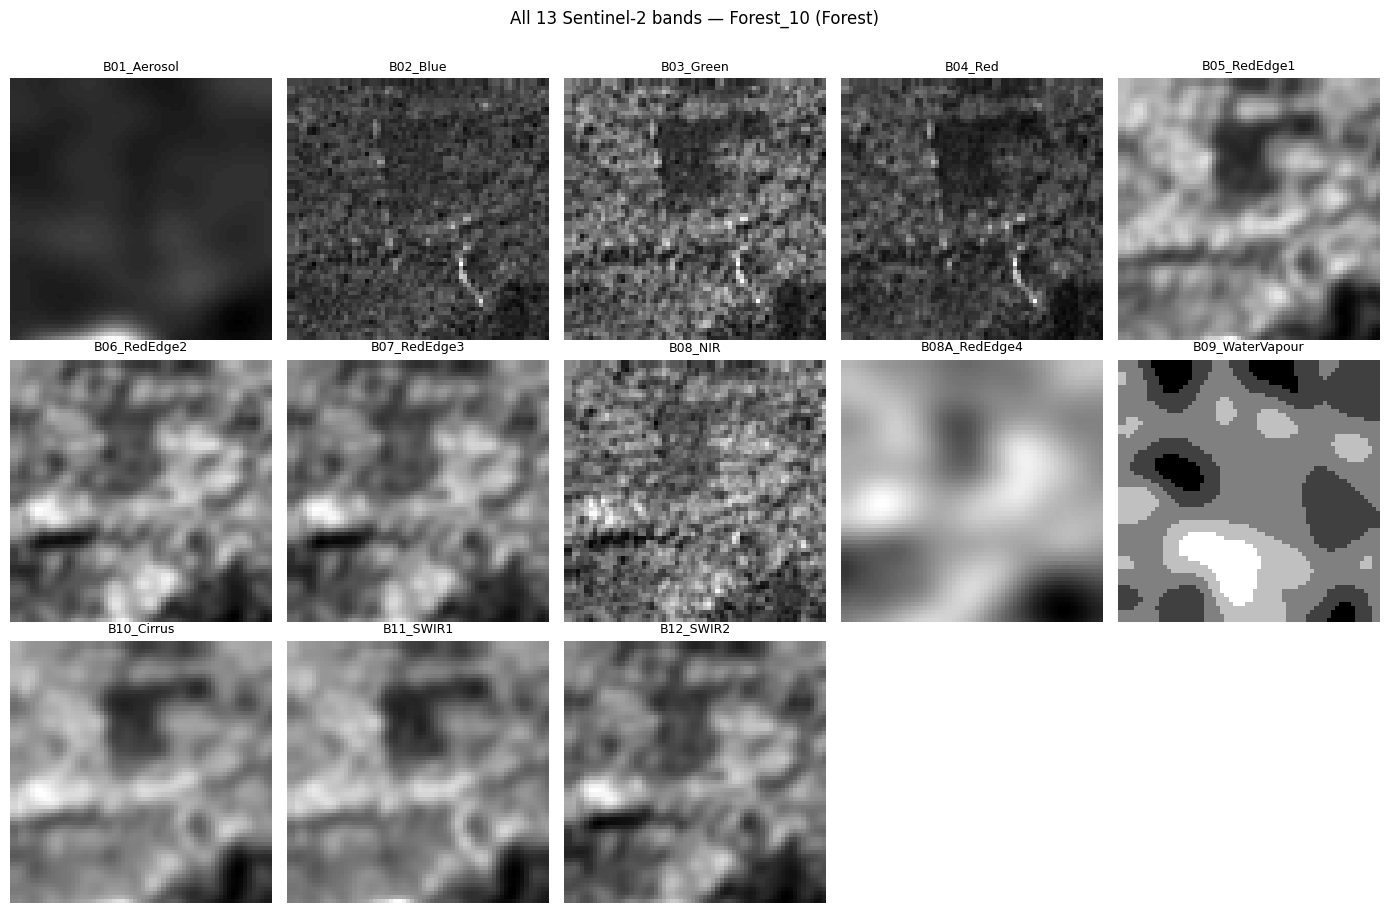

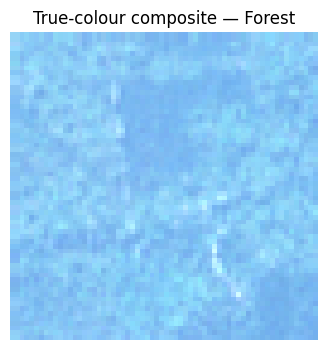

In [11]:
# Pick a vegetated patch (Forest) — most illustrative for NIR/red-edge contrast
veg = index_df[index_df.class_label == "Forest"].iloc[1]
with rasterio.open(veg.ms_path) as src:
    bands = src.read()  # (13, 64, 64)

fig, axes = plt.subplots(3, 5, figsize=(14, 9))
for b, ax in enumerate(axes.ravel()):
    if b < len(BAND_NAMES):
        ax.imshow(bands[b], cmap="gray")
        ax.set_title(BAND_NAMES[b], fontsize=9)
    ax.axis("off")
plt.suptitle(f"All 13 Sentinel-2 bands — {veg.patch_id} ({veg.class_label})", y=1.01)
plt.tight_layout()
plt.show()

# True-colour composite (B04=Red, B03=Green, B02=Blue) for contrast.
# Bands are 0-indexed in the array: B02->1, B03->2, B04->3.
rgb_composite = np.dstack([bands[3], bands[2], bands[1]]).astype(float)
rgb_composite = np.clip(rgb_composite / np.percentile(rgb_composite, 99), 0, 1)  # simple stretch
plt.figure(figsize=(4, 4))
plt.imshow(rgb_composite)
plt.title(f"True-colour composite — {veg.class_label}")
plt.axis("off")
plt.show()

### Reproducible stratified 80/20 split

In [12]:
train_df, test_df = train_test_split(
    index_df,
    test_size=TEST_FRACTION,
    stratify=index_df["class_label"],
    random_state=RANDOM_SEED,
)

# Record the split back on the unified index
index_df["split"] = "train"
index_df.loc[test_df.index, "split"] = "test"

print(f"Train: {len(train_df)}  |  Test: {len(test_df)}")

# Verify stratification preserved class proportions
proportions = pd.crosstab(
    index_df["class_label"], index_df["split"], normalize="columns"
).round(3)
print("\nClass proportions by split (should match closely):")
proportions

Train: 21600  |  Test: 5400

Class proportions by split (should match closely):


split,test,train
class_label,,
AnnualCrop,0.111,0.111
Forest,0.111,0.111
HerbaceousVegetation,0.111,0.111
Highway,0.093,0.093
Industrial,0.093,0.093
Pasture,0.074,0.074
PermanentCrop,0.093,0.093
Residential,0.111,0.111
River,0.093,0.093


In [13]:
OUTPUT_INDEX = Path("data_index.csv")
index_df.to_csv(OUTPUT_INDEX, index=False)
print(f"Saved index with split to: {OUTPUT_INDEX.resolve()}")
print(f"Columns: {list(index_df.columns)}")
index_df.head()

Saved index with split to: /Users/anikghosh/Desktop/test/Satellite Image Classification/data_index.csv
Columns: ['patch_id', 'class_label', 'rgb_path', 'ms_path', 'split']


,patch_id,class_label,rgb_path,ms_path,split
0,AnnualCrop_1,AnnualCrop,datasets/EuroSAT_RGB/AnnualCrop/AnnualCrop_1.jpg,datasets/EuroSAT_MS/AnnualCrop/AnnualCrop_1.tif,train
1,AnnualCrop_10,AnnualCrop,datasets/EuroSAT_RGB/AnnualCrop/AnnualCrop_10.jpg,datasets/EuroSAT_MS/AnnualCrop/AnnualCrop_10.tif,test
2,AnnualCrop_100,AnnualCrop,datasets/EuroSAT_RGB/AnnualCrop/AnnualCrop_100...,datasets/EuroSAT_MS/AnnualCrop/AnnualCrop_100.tif,train
3,AnnualCrop_1000,AnnualCrop,datasets/EuroSAT_RGB/AnnualCrop/AnnualCrop_100...,datasets/EuroSAT_MS/AnnualCrop/AnnualCrop_1000...,train
4,AnnualCrop_1001,AnnualCrop,datasets/EuroSAT_RGB/AnnualCrop/AnnualCrop_100...,datasets/EuroSAT_MS/AnnualCrop/AnnualCrop_1001...,test


# RGB Baseline

This establishes the **reference point** for the whole assessment a model trained on
RGB bands only. Every multispectral result measured against these numbers.



In [36]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix

# ---- Reproducibility ----
RANDOM_SEED = 42

def seed_everything(seed: int = RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ---- Config ----
CLASS_NAMES = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway", "Industrial",
    "Pasture", "PermanentCrop", "Residential", "River", "SeaLake",
]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

EPOCHS = 20          # reduce to ~8-10 if CPU-bound; baseline is solid by then
BATCH_SIZE = 64
LR = 1e-3
VAL_FRACTION = 0.10  # carved out of the TRAIN split for monitoring
NUM_WORKERS = 0      # set to 0 if you hit worker issues in the notebook

ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)

# ---- Load the M1 index ----
index_df = pd.read_csv("data_index.csv")
index_df["target"] = index_df["class_label"].map(CLASS_TO_IDX)

train_pool = index_df[index_df.split == "train"].reset_index(drop=True)
test_df    = index_df[index_df.split == "test"].reset_index(drop=True)
print(f"Train pool: {len(train_pool)}  |  Test: {len(test_df)}")

Device: mps
Train pool: 21600  |  Test: 5400


### normalisation and computing stats

In [15]:
def compute_rgb_stats(df: pd.DataFrame, n: int = 1000, seed: int = RANDOM_SEED):
    """Per-channel mean/std over a sample of RGB train images, in [0, 1]."""
    sample = df.sample(n=min(n, len(df)), random_state=seed)
    pixels = []
    for path in sample["rgb_path"]:
        arr = np.asarray(Image.open(path), dtype=np.float32) / 255.0  # (H, W, 3)
        pixels.append(arr.reshape(-1, 3))
    pixels = np.concatenate(pixels, axis=0)
    mean = pixels.mean(axis=0)
    std = pixels.std(axis=0)
    return mean.astype(np.float32), std.astype(np.float32)

RGB_MEAN, RGB_STD = compute_rgb_stats(train_pool)
print(f"RGB mean (R,G,B): {RGB_MEAN.round(4)}")
print(f"RGB std  (R,G,B): {RGB_STD.round(4)}")

RGB mean (R,G,B): [0.3487 0.3836 0.41  ]
RGB std  (R,G,B): [0.2072 0.1403 0.1186]


### Dataset and augmentation

The dataset loads an RGB JPG, scales to [0, 1], standardises with the train statistics,
and returns a channels-first `(3, 64, 64)` tensor.

**Augmentation** is domain-aware: satellite patches have no canonical orientation, so
horizontal/vertical flips and 90° rotations are label-preserving and cheap. Augmentation
is applied to **training samples only** — validation and test are evaluated clean.

In [16]:
def augment(img: torch.Tensor) -> torch.Tensor:
    """Random flips + 90-degree rotation on a (C, H, W) tensor. Orientation-invariant."""
    if random.random() < 0.5:
        img = torch.flip(img, dims=[2])              # horizontal
    if random.random() < 0.5:
        img = torch.flip(img, dims=[1])              # vertical
    k = random.randint(0, 3)
    if k:
        img = torch.rot90(img, k, dims=[1, 2])       # 0/90/180/270 degrees
    return img

class EuroSATRGB(Dataset):
    def __init__(self, df: pd.DataFrame, mean, std, train: bool = False):
        self.df = df.reset_index(drop=True)
        self.mean = torch.tensor(mean).view(3, 1, 1)
        self.std = torch.tensor(std).view(3, 1, 1)
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        arr = np.asarray(Image.open(row.rgb_path), dtype=np.float32) / 255.0  # (H,W,3)
        img = torch.from_numpy(arr).permute(2, 0, 1)                          # (3,H,W)
        img = (img - self.mean) / self.std
        if self.train:
            img = augment(img)
        return img, int(row.target)

In [19]:
# Carve a validation set out of the train pool (stratified, seeded).
# The M1 test split is never touched here.
from sklearn.model_selection import train_test_split

tr_df, val_df = train_test_split(
    train_pool,
    test_size=VAL_FRACTION,
    stratify=train_pool["target"],
    random_state=RANDOM_SEED,
)

train_ds = EuroSATRGB(tr_df,  RGB_MEAN, RGB_STD, train=True)
val_ds   = EuroSATRGB(val_df, RGB_MEAN, RGB_STD, train=False)
test_ds  = EuroSATRGB(test_df, RGB_MEAN, RGB_STD, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, drop_last=False)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
xb, yb = next(iter(train_loader))
print(f"Batch tensor: {tuple(xb.shape)}  labels: {tuple(yb.shape)}")

Train: 19440 | Val: 2160 | Test: 5400
Batch tensor: (64, 3, 64, 64)  labels: (64,)


### Model

A compact 4-block CNN: conv → batch-norm → ReLU → max-pool, widening 32 → 64 → 128 →
128 channels, then global average pooling, dropout, and a linear classifier. 



In [20]:
class CompactCNN(nn.Module):
    def __init__(self, in_channels: int = 3, num_classes: int = 10, p_drop: float = 0.3):
        super().__init__()

        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            block(in_channels, 32),   # 64 -> 32
            block(32, 64),            # 32 -> 16
            block(64, 128),           # 16 -> 8
            block(128, 128),          # 8  -> 4
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p_drop),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.head(self.features(x))

model = CompactCNN(in_channels=3, num_classes=len(CLASS_NAMES)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")

Parameters: 242,474


### Training

Adam optimiser, cross-entropy loss. We track train/validation loss and accuracy each
epoch and keep the **best validation-accuracy checkpoint** for final test evaluation —
standard model selection that avoids reporting an over- or under-fit final epoch.

In [21]:
@torch.no_grad()
def evaluate(model, loader):
    """Return (avg_loss, accuracy, all_preds, all_targets) over a loader."""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, correct, n = 0.0, 0, 0
    preds_all, targets_all = [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        total_loss += criterion(logits, yb).item() * xb.size(0)
        preds = logits.argmax(1)
        correct += (preds == yb).sum().item()
        n += xb.size(0)
        preds_all.append(preds.cpu())
        targets_all.append(yb.cpu())
    return (total_loss / n, correct / n,
            torch.cat(preds_all).numpy(), torch.cat(targets_all).numpy())

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc, best_state = 0.0, None

    for epoch in range(1, epochs + 1):
        model.train()
        run_loss, correct, n = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            n += xb.size(0)

        train_loss, train_acc = run_loss / n, correct / n
        val_loss, val_acc, _, _ = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"train loss {train_loss:.3f} acc {train_acc:.3f} | "
              f"val loss {val_loss:.3f} acc {val_acc:.3f}")

    model.load_state_dict(best_state)  # restore best checkpoint
    print(f"\nBest validation accuracy: {best_val_acc:.3f}")
    return model, history

In [22]:
seed_everything()  # ensure identical init/shuffling for the RGB run
model, history = train_model(model, train_loader, val_loader)

Epoch 01/20 | train loss 0.874 acc 0.699 | val loss 0.584 acc 0.804
Epoch 02/20 | train loss 0.588 acc 0.797 | val loss 0.506 acc 0.827
Epoch 03/20 | train loss 0.478 acc 0.834 | val loss 0.457 acc 0.838
Epoch 04/20 | train loss 0.426 acc 0.854 | val loss 0.335 acc 0.887
Epoch 05/20 | train loss 0.366 acc 0.873 | val loss 0.325 acc 0.894
Epoch 06/20 | train loss 0.337 acc 0.884 | val loss 0.300 acc 0.896
Epoch 07/20 | train loss 0.305 acc 0.894 | val loss 0.256 acc 0.911
Epoch 08/20 | train loss 0.292 acc 0.901 | val loss 0.258 acc 0.909
Epoch 09/20 | train loss 0.279 acc 0.900 | val loss 0.290 acc 0.902
Epoch 10/20 | train loss 0.258 acc 0.912 | val loss 0.231 acc 0.918
Epoch 11/20 | train loss 0.256 acc 0.913 | val loss 0.239 acc 0.919
Epoch 12/20 | train loss 0.236 acc 0.918 | val loss 0.222 acc 0.926
Epoch 13/20 | train loss 0.229 acc 0.922 | val loss 0.246 acc 0.911
Epoch 14/20 | train loss 0.222 acc 0.922 | val loss 0.170 acc 0.946
Epoch 15/20 | train loss 0.213 acc 0.927 | val l

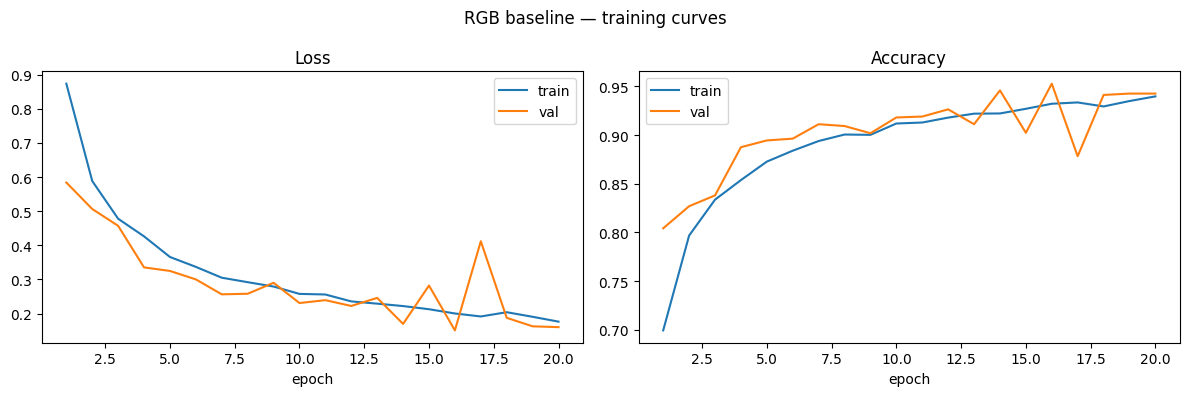

In [23]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="train")
axes[1].plot(epochs_range, history["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()

plt.suptitle("RGB baseline — training curves")
plt.tight_layout()
plt.show()

### Test evaluation — per-class metrics

The held-out test set is evaluated **once**, with the best-validation checkpoint. We
report per-class precision, recall, and F1 (not just overall accuracy) because EuroSAT
is mildly imbalanced and because the per-class view is where the multispectral story
will later show up — we expect vegetation-type classes (AnnualCrop, PermanentCrop,
Pasture, HerbaceousVegetation) to be the weakest in RGB.

In [24]:
test_loss, test_acc, test_preds, test_targets = evaluate(model, test_loader)
print(f"Test accuracy: {test_acc:.4f}  |  Test loss: {test_loss:.4f}\n")

report = classification_report(
    test_targets, test_preds, target_names=CLASS_NAMES, digits=3, output_dict=True
)
print(classification_report(test_targets, test_preds, target_names=CLASS_NAMES, digits=3))

Test accuracy: 0.9430  |  Test loss: 0.1715

                      precision    recall  f1-score   support

          AnnualCrop      0.949     0.863     0.904       600
              Forest      0.990     0.975     0.982       600
HerbaceousVegetation      0.912     0.928     0.920       600
             Highway      0.945     0.936     0.941       500
          Industrial      0.990     0.944     0.966       500
             Pasture      0.962     0.940     0.951       400
       PermanentCrop      0.834     0.932     0.880       500
         Residential      0.975     0.988     0.982       600
               River      0.894     0.940     0.916       500
             SeaLake      0.985     0.978     0.982       600

            accuracy                          0.943      5400
           macro avg      0.943     0.943     0.942      5400
        weighted avg      0.945     0.943     0.943      5400



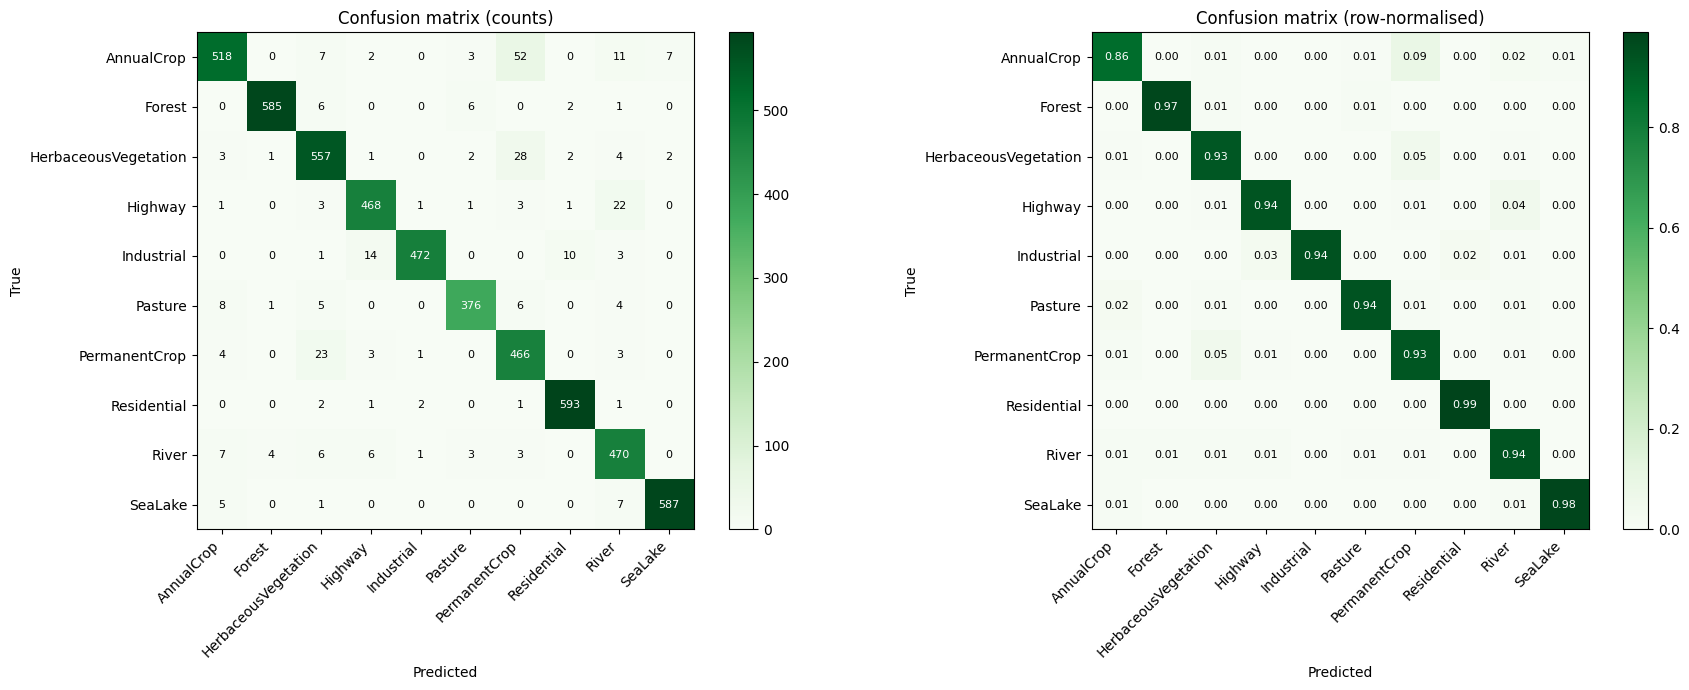

In [25]:
# Confusion matrix (raw counts + row-normalised) — no seaborn dependency
cm = confusion_matrix(test_targets, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, mat, title, fmt in [
    (axes[0], cm, "Confusion matrix (counts)", "d"),
    (axes[1], cm_norm, "Confusion matrix (row-normalised)", ".2f"),
]:
    im = ax.imshow(mat, cmap="Greens")
    ax.set_xticks(range(len(CLASS_NAMES))); ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    thresh = mat.max() / 2
    for r in range(mat.shape[0]):
        for c in range(mat.shape[1]):
            val = format(mat[r, c], fmt)
            ax.text(c, r, val, ha="center", va="center",
                    color="white" if mat[r, c] > thresh else "black", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

### Sample predictions

A qualitative look at test predictions — the "subjective assessment using sample
results" the brief asks for. Correct predictions are titled in green, errors in red,
so failure cases are easy to spot.

Random test predictions:


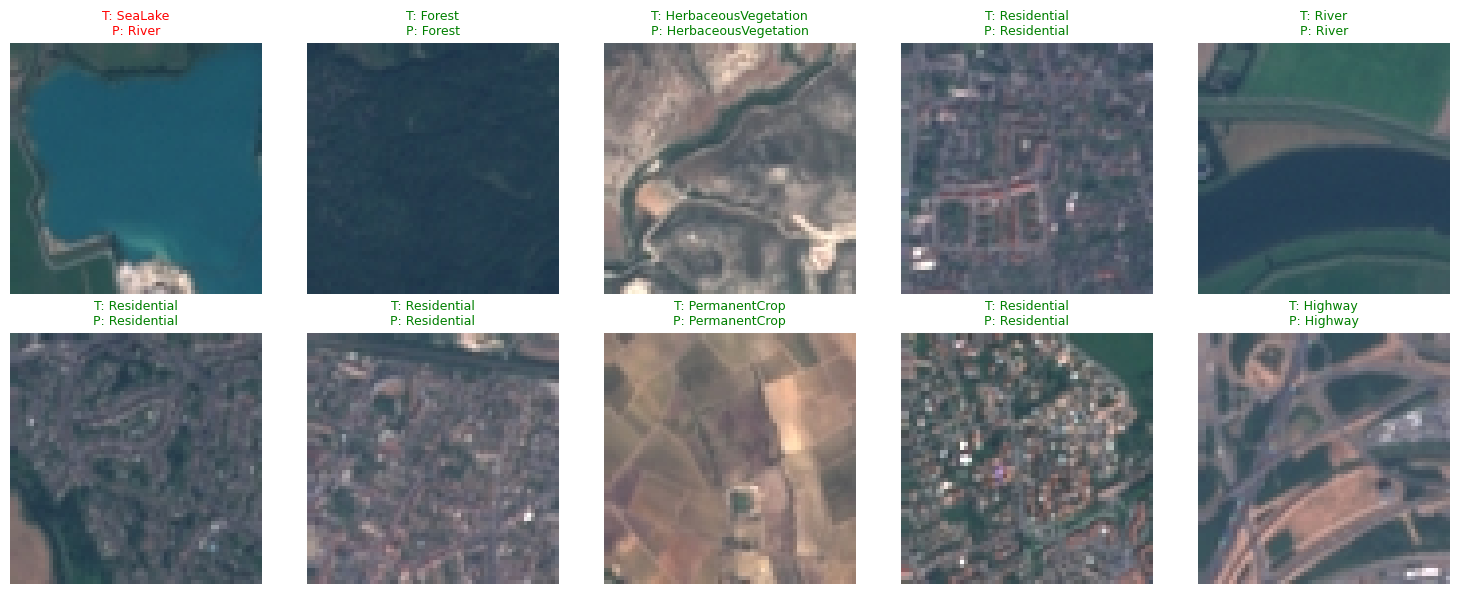

Misclassified test examples:


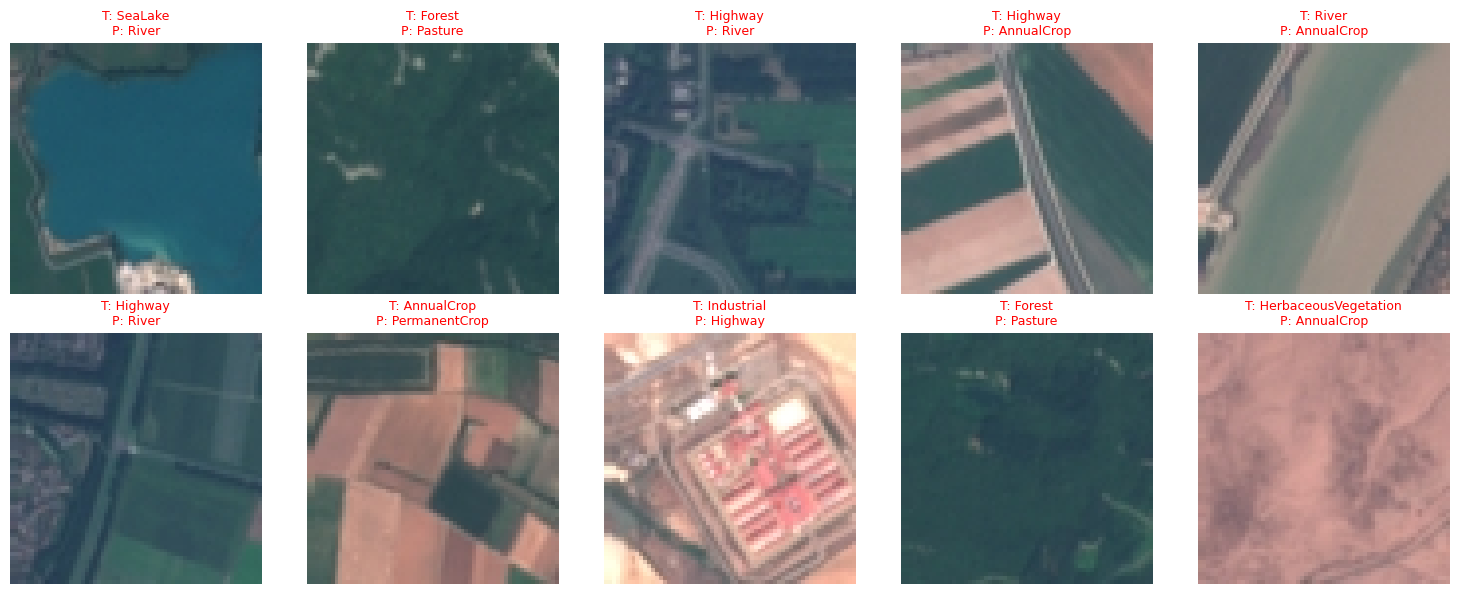

In [26]:
# De-normalise for display
inv_mean = torch.tensor(RGB_MEAN).view(3, 1, 1)
inv_std = torch.tensor(RGB_STD).view(3, 1, 1)

def show_samples(df, n=10, only_errors=False):
    ds = EuroSATRGB(df, RGB_MEAN, RGB_STD, train=False)
    idxs = list(range(len(ds)))
    random.Random(RANDOM_SEED).shuffle(idxs)

    picked = []
    model.eval()
    with torch.no_grad():
        for i in idxs:
            img, target = ds[i]
            pred = model(img.unsqueeze(0).to(DEVICE)).argmax(1).item()
            if only_errors and pred == target:
                continue
            picked.append((img, target, pred))
            if len(picked) == n:
                break

    cols = 5
    rows = (len(picked) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    for ax, (img, target, pred) in zip(axes.ravel(), picked):
        disp = (img * inv_std + inv_mean).permute(1, 2, 0).clamp(0, 1).numpy()
        ax.imshow(disp)
        correct = pred == target
        ax.set_title(f"T: {CLASS_NAMES[target]}\nP: {CLASS_NAMES[pred]}",
                     fontsize=9, color="green" if correct else "red")
        ax.axis("off")
    for ax in axes.ravel()[len(picked):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

print("Random test predictions:")
show_samples(test_df, n=10)

print("Misclassified test examples:")
show_samples(test_df, n=10, only_errors=True)

In [47]:
# Persist artifacts so M3/M4 compare against an identical reference.
torch.save(model.state_dict(), ARTIFACTS / "rgb_baseline.pt")

pred_df = test_df[["patch_id", "class_label"]].copy()
pred_df["true_idx"] = test_targets
pred_df["pred_idx"] = test_preds
pred_df["pred_label"] = [CLASS_NAMES[p] for p in test_preds]
pred_df["correct"] = pred_df["true_idx"] == pred_df["pred_idx"]
# pred_df.to_csv(ARTIFACTS / "rgb_test_predictions.csv", index=False)
pred_df.to_csv(ARTIFACTS / "rgb_baseline_test_predictions.csv", index=False)

metrics_out = {
    "model": "rgb_baseline",
    "in_channels": 3,
    "test_accuracy": float(test_acc),
    "test_loss": float(test_loss),
    "per_class": {c: report[c] for c in CLASS_NAMES},
    "macro_f1": report["macro avg"]["f1-score"],
    "weighted_f1": report["weighted avg"]["f1-score"],
    "epochs": EPOCHS, "batch_size": BATCH_SIZE, "lr": LR, "seed": RANDOM_SEED,
}
# with open(ARTIFACTS / "rgb_metrics.json", "w") as f:
with open(ARTIFACTS / "rgb_baseline_metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

print("Saved: rgb_baseline.pt, rgb_test_predictions.csv, rgb_metrics.json")
print(f"Headline — test accuracy {test_acc:.4f}, macro-F1 {report['macro avg']['f1-score']:.4f}")

Saved: rgb_baseline.pt, rgb_test_predictions.csv, rgb_metrics.json
Headline — test accuracy 0.9646, macro-F1 0.9631


# 3 Multispectral Approach

In the previous steps we performed image classification of the patches using RGB channels which is our baseline.  
Now we focus on using multispectral approach to answer the question : **does information beyond the visible bands improve land-use classification?**

To make the comparison fair, **only the input channels change**. The architecture
(`CompactCNN`), training schedule, optimiser, augmentation, seeds, and the train/val/test
split are all identical to the previous approach. Any accuracy difference is therefore attributable to
spectral information, not to a different model  

**Three configurations, compared like-for-like:**

| Variant         | Channels | Input                                   | Question it answers |
|-----------------|----------|-----------------------------------------|---------------------|
| `rgb_baseline`  | 3        | Blue, Green, Red (from M2)              | Visible-only reference |
| `rgb_indices`   | 6        | RGB + NDVI + NDWI + NDBI                | Do engineered spectral indices help? |
| `ms_allbands`   | 12       | All 13 bands minus B10 (Cirrus)         | Do all raw spectral bands help? |

We reuse `CompactCNN`, `train_model`, `evaluate`, `augment`, and `seed_everything`
from baseline — only a new multispectral `Dataset` and per-variant normalisation are added.

In [50]:
import json
import rasterio
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Sentinel-2 L2A reflectance scale factor. Dividing by this puts raw 16-bit DN values
# into physical reflectance (~0-1). It improves numerical stability when computing
# statistics; standardisation would absorb the scale anyway, but indices are cleaner
# and precision is better with small values.
S2_SCALE = 10000.0

def read_ms(path):
    """Read a 13-band GeoTIFF as (13, H, W) float32 reflectance."""
    with rasterio.open(path) as src:
        raw = src.read().astype(np.float32)   # (13, H, W), channels-first
    return raw / S2_SCALE

# Band index reference (0-indexed into the 13-band array), from M1:
#  0 B01 Aerosol | 1 B02 Blue | 2 B03 Green | 3 B04 Red | 4 B05 RedEdge1
#  5 B06 RedEdge2 | 6 B07 RedEdge3 | 7 B08 NIR | 8 B08A RedEdge4
#  9 B09 WaterVapour | 10 B10 Cirrus | 11 B11 SWIR1 | 12 B12 SWIR2
B_BLUE, B_GREEN, B_RED, B_NIR, B_SWIR1 = 1, 2, 3, 7, 11
print("Setup ready — reusing previous training machinery.")

Setup ready — reusing previous training machinery.


### Spectral indices

Indices are cheap, physically-motivated features that encode band relationships the
network would otherwise have to learn from scratch:

- **NDVI** = (NIR − Red) / (NIR + Red) — vegetation vigour. Healthy vegetation reflects
  NIR strongly and absorbs red, so NDVI is high for forest/crops, low for built-up/water.
  Most relevant for separating the vegetation classes RGB struggles with.
- **NDWI** = (Green − NIR) / (Green + NIR) — open water. High over River and Sea/Lake.
- **NDBI** = (SWIR1 − NIR) / (SWIR1 + NIR) — built-up surfaces. Helps Industrial and
  Residential.

Indices are **ratios, so they are invariant to the reflectance scale factor** — they
come out identical whether computed on raw DN or scaled reflectance.

In [51]:
def compute_indices(raw):
    """raw: (13, H, W) reflectance. Returns dict of named (H, W) index maps."""
    eps = 1e-6
    green, red = raw[B_GREEN], raw[B_RED]
    nir, swir1 = raw[B_NIR], raw[B_SWIR1]
    return {
        "NDVI": (nir - red)   / (nir + red   + eps),
        "NDWI": (green - nir) / (green + nir + eps),
        "NDBI": (swir1 - nir) / (swir1 + nir + eps),
    }

def build_channels(raw, band_indices, index_names):
    """Stack selected raw bands + computed indices into (C, H, W)."""
    channels = [raw[b] for b in band_indices]
    if index_names:
        idx = compute_indices(raw)
        channels += [idx[name] for name in index_names]
    return np.stack(channels, axis=0)

Before training, confirm the indices respond correctly: NDVI should light up on
vegetation, NDWI on water, NDBI on built-up areas.

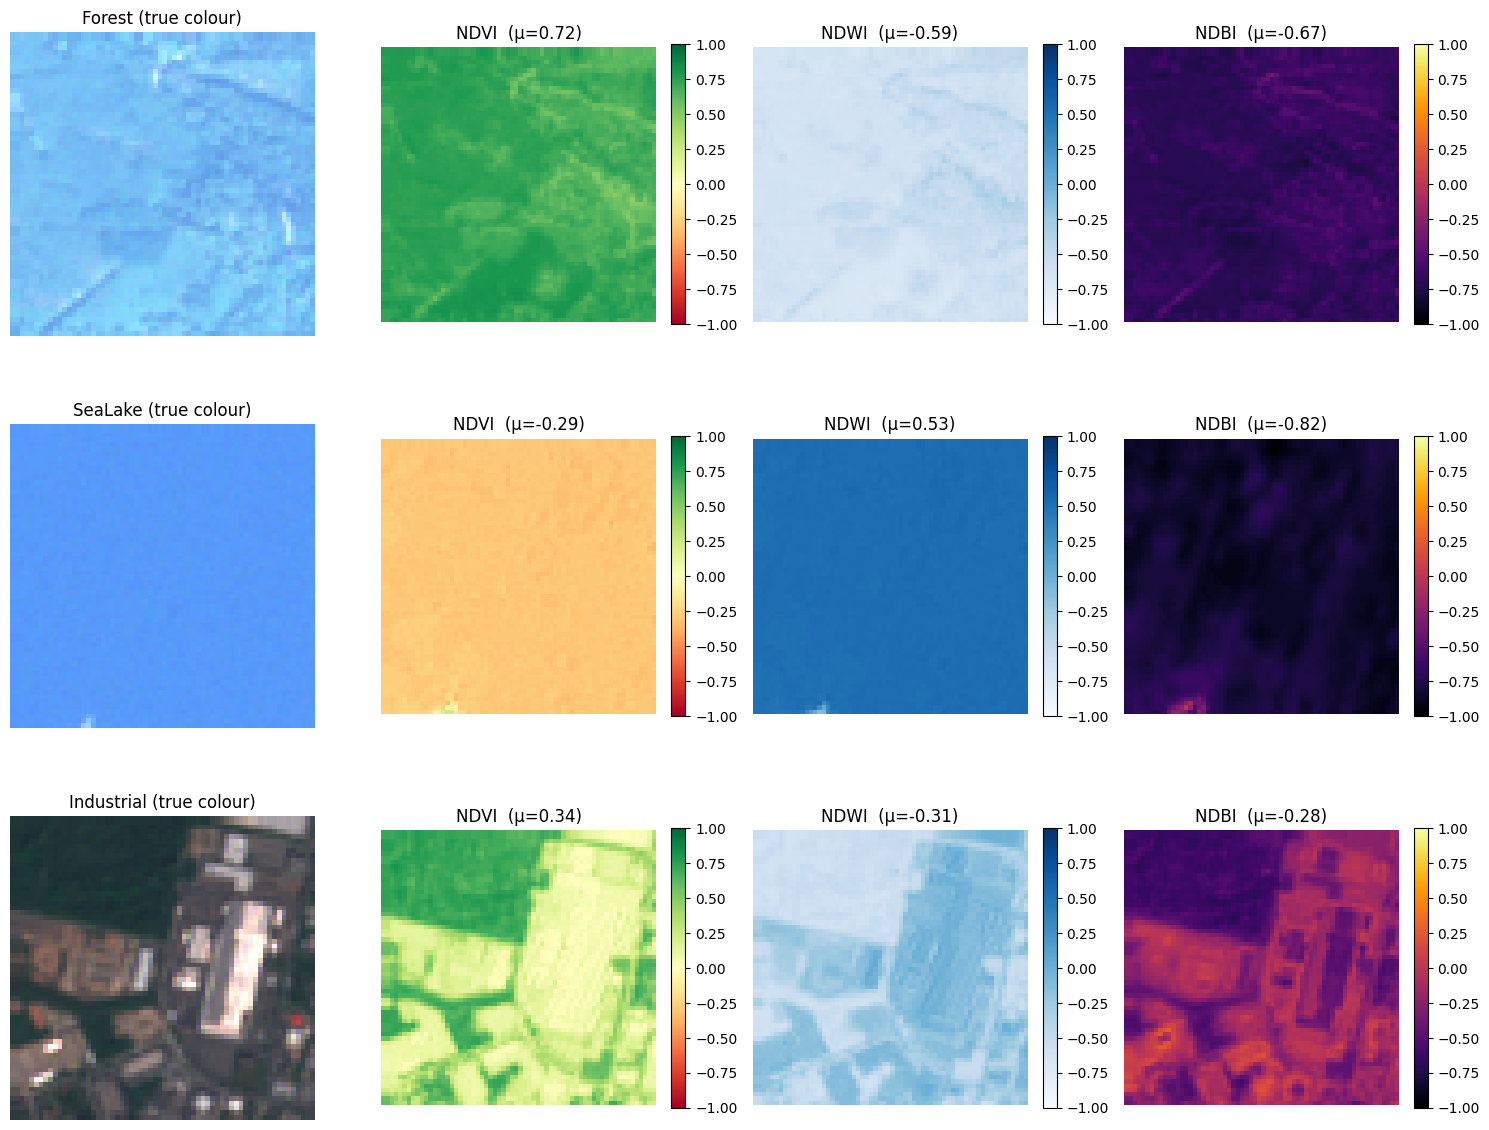

In [52]:
# One patch each: vegetated, water, urban
examples = {
    "Forest": "vegetation", "SeaLake": "water", "Industrial": "built-up",
}
full_index = pd.read_csv("data_index.csv")

fig, axes = plt.subplots(len(examples), 4, figsize=(15, 4 * len(examples)))
for r, (cls, _) in enumerate(examples.items()):
    row = full_index[full_index.class_label == cls].iloc[0]
    raw = read_ms(row.ms_path)
    idx = compute_indices(raw)

    # True-colour composite for reference
    tc = np.dstack([raw[B_RED], raw[B_GREEN], raw[B_BLUE]])
    tc = np.clip(tc / np.percentile(tc, 99), 0, 1)
    axes[r, 0].imshow(tc); axes[r, 0].set_title(f"{cls} (true colour)")

    for c, (name, cmap) in enumerate(
        [("NDVI", "RdYlGn"), ("NDWI", "Blues"), ("NDBI", "inferno")], start=1
    ):
        im = axes[r, c].imshow(idx[name], cmap=cmap, vmin=-1, vmax=1)
        axes[r, c].set_title(f"{name}  (μ={idx[name].mean():.2f})")
        fig.colorbar(im, ax=axes[r, c], fraction=0.046)
    for c in range(4):
        axes[r, c].axis("off")
plt.tight_layout()
plt.show()

### Variant configurations

Each variant is fully specified by which raw bands to feed and which indices to append.
A single dataset class then handles all of them.

In [53]:
ALL_BANDS = list(range(13))
NO_CIRRUS = [b for b in ALL_BANDS if b != 10]   # drop B10 (near-empty over land)
RGB_BANDS = [B_BLUE, B_GREEN, B_RED]

VARIANTS = {
    "rgb_indices": {"bands": RGB_BANDS, "indices": ["NDVI", "NDWI", "NDBI"]},  # 6 ch
    "ms_allbands": {"bands": NO_CIRRUS, "indices": []},                        # 12 ch
}

for name, cfg in VARIANTS.items():
    n_ch = len(cfg["bands"]) + len(cfg["indices"])
    print(f"{name:14s} -> {n_ch} channels  (bands={len(cfg['bands'])}, indices={cfg['indices']})")

rgb_indices    -> 6 channels  (bands=3, indices=['NDVI', 'NDWI', 'NDBI'])
ms_allbands    -> 12 channels  (bands=12, indices=[])


### Per-variant normalisation and dataset

Normalisation stats are **per-channel, computed on the training split only** (no test
leakage), and recomputed per variant because each has a different channel composition.
We standardise each channel independently, which naturally handles the fact that raw
bands (~0–1 reflectance) and indices (~−1 to 1) live on different scales.

The dataset mirrors M2's exactly — same augmentation, same channels-first tensor output
— so the only moving part between RGB and multispectral is the input.

In [63]:
def compute_ms_stats(df, band_indices, index_names, n=500, seed=RANDOM_SEED):
    """Streaming per-channel mean/std over a sample of train patches."""
    sample = df.sample(n=min(n, len(df)), random_state=seed)
    sums = sqsums = None
    count = 0
    for path in sample["ms_path"]:
        chans = build_channels(read_ms(path), band_indices, index_names)  # (C,H,W)
        flat = chans.reshape(chans.shape[0], -1)
        s, sq = flat.sum(1), (flat ** 2).sum(1)
        sums = s if sums is None else sums + s
        sqsums = sq if sqsums is None else sqsums + sq
        count += flat.shape[1]
    mean = sums / count
    std = np.sqrt(np.maximum(sqsums / count - mean ** 2, 1e-12))
    return mean.astype(np.float32), std.astype(np.float32)

class EuroSATMS(Dataset):
    def __init__(self, df, band_indices, index_names, mean, std, train=False):
        self.df = df.reset_index(drop=True)
        self.band_indices = band_indices
        self.index_names = index_names
        self.mean = torch.tensor(mean).view(-1, 1, 1)
        self.std = torch.tensor(std).view(-1, 1, 1)
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        chans = build_channels(read_ms(row.ms_path), self.band_indices, self.index_names)
        img = torch.from_numpy(chans)
        img = (img - self.mean) / self.std
        if self.train:
            img = augment(img)   # reused from M2; spatial-only, applies to all channels
        return img, int(row.target)

### Train each multispectral variant

We loop over the variants, re-seeding before each so model initialisation and data
shuffling match the RGB run. Each variant is trained, the best-validation checkpoint is
selected, and the held-out test set is evaluated once.

**Runtime note:** this trains two models. On CPU budget roughly the same per-variant time
as M2. Reduce `EPOCHS` if needed — the comparison only requires all models to train under
identical settings, not to be trained to exhaustion.

In [64]:
ms_results = {}

for name, cfg in VARIANTS.items():
    in_ch = len(cfg["bands"]) + len(cfg["indices"])
    print(f"\n{'='*64}\nVariant: {name}  ({in_ch} channels)\n{'='*64}")

    mean, std = compute_ms_stats(tr_df, cfg["bands"], cfg["indices"])

    loaders = {}
    for split_name, sdf, is_train in [
        ("train", tr_df, True), ("val", val_df, False), ("test", test_df, False)
    ]:
        ds = EuroSATMS(sdf, cfg["bands"], cfg["indices"], mean, std, train=is_train)
        loaders[split_name] = DataLoader(
            ds, batch_size=BATCH_SIZE, shuffle=is_train, num_workers=NUM_WORKERS
        )

    seed_everything()  # identical init/shuffle to the RGB baseline
    ms_model = CompactCNN(in_channels=in_ch, num_classes=len(CLASS_NAMES)).to(DEVICE)
    ms_model, hist = train_model(ms_model, loaders["train"], loaders["val"])

    test_loss, test_acc, preds, targets = evaluate(ms_model, loaders["test"])
    report = classification_report(
        targets, preds, target_names=CLASS_NAMES, digits=3, output_dict=True
    )

    ms_results[name] = {
        "model": ms_model, "history": hist, "in_channels": in_ch, "cfg": cfg,
        "mean": mean, "std": std, "test_acc": test_acc, "test_loss": test_loss,
        "preds": preds, "targets": targets, "report": report,
    }
    print(f"\n>> {name}: test acc {test_acc:.4f} | "
          f"macro-F1 {report['macro avg']['f1-score']:.3f}")


Variant: rgb_indices  (6 channels)
Epoch 01/20 | train loss 0.599 acc 0.802 | val loss 0.396 acc 0.865
Epoch 02/20 | train loss 0.363 acc 0.877 | val loss 0.271 acc 0.900
Epoch 03/20 | train loss 0.294 acc 0.901 | val loss 0.284 acc 0.904
Epoch 04/20 | train loss 0.263 acc 0.912 | val loss 0.236 acc 0.920
Epoch 05/20 | train loss 0.234 acc 0.920 | val loss 0.206 acc 0.933
Epoch 06/20 | train loss 0.218 acc 0.927 | val loss 0.186 acc 0.933
Epoch 07/20 | train loss 0.197 acc 0.933 | val loss 0.164 acc 0.947
Epoch 08/20 | train loss 0.183 acc 0.937 | val loss 0.154 acc 0.945
Epoch 09/20 | train loss 0.173 acc 0.942 | val loss 0.142 acc 0.955
Epoch 10/20 | train loss 0.166 acc 0.943 | val loss 0.193 acc 0.935
Epoch 11/20 | train loss 0.153 acc 0.946 | val loss 0.120 acc 0.961
Epoch 12/20 | train loss 0.149 acc 0.948 | val loss 0.113 acc 0.962
Epoch 13/20 | train loss 0.142 acc 0.950 | val loss 0.151 acc 0.953
Epoch 14/20 | train loss 0.136 acc 0.954 | val loss 0.117 acc 0.962
Epoch 15/20 

### Comparison against the RGB baseline

A first look at whether multispectral information helps overall and, more importantly,
**per class**. The deeper interpretation — confusion-matrix differences and the physical
explanation — is the focus of M4; here we confirm the experiment ran cleanly and surface
the headline deltas.

Expect the gains to be **concentrated, not uniform**: the largest improvements should
appear in the vegetation-type classes (AnnualCrop, PermanentCrop, Pasture,
HerbaceousVegetation), where NIR and red-edge information separates classes that look
near-identical in RGB. Overall-accuracy gains on EuroSAT are typically modest because RGB
is already strong — the per-class view is where the story lives.

In [65]:
with open(ARTIFACTS / "rgb_metrics.json") as f:
    rgb_metrics = json.load(f)

# Overall comparison table
rows = [{
    "variant": "rgb_baseline", "channels": 3,
    "test_acc": rgb_metrics["test_accuracy"],
    "macro_f1": rgb_metrics["macro_f1"], "acc_delta": 0.0,
}]
for name, r in ms_results.items():
    rows.append({
        "variant": name, "channels": r["in_channels"],
        "test_acc": r["test_acc"],
        "macro_f1": r["report"]["macro avg"]["f1-score"],
        "acc_delta": r["test_acc"] - rgb_metrics["test_accuracy"],
    })
summary = pd.DataFrame(rows).round(4)
print("Overall comparison:")
print(summary.to_string(index=False))

# Per-class F1 deltas vs RGB
per_class = pd.DataFrame({"class": CLASS_NAMES})
per_class["rgb_f1"] = [rgb_metrics["per_class"][c]["f1-score"] for c in CLASS_NAMES]
for name, r in ms_results.items():
    f1s = [r["report"][c]["f1-score"] for c in CLASS_NAMES]
    per_class[f"{name}_Δf1"] = np.array(f1s) - per_class["rgb_f1"].values
per_class = per_class.round(3)
print("\nPer-class F1 vs RGB (positive = multispectral better):")
print(per_class.to_string(index=False))

Overall comparison:
     variant  channels  test_acc  macro_f1  acc_delta
rgb_baseline         3    0.9430    0.9424     0.0000
 rgb_indices         6    0.9591    0.9571     0.0161
 ms_allbands        12    0.9696    0.9687     0.0267

Per-class F1 vs RGB (positive = multispectral better):
               class  rgb_f1  rgb_indices_Δf1  ms_allbands_Δf1
          AnnualCrop   0.904            0.046            0.049
              Forest   0.982            0.000            0.007
HerbaceousVegetation   0.920            0.023            0.052
             Highway   0.941            0.030            0.024
          Industrial   0.966           -0.013            0.004
             Pasture   0.951           -0.043            0.002
       PermanentCrop   0.880            0.044            0.066
         Residential   0.982           -0.021           -0.013
               River   0.916            0.066            0.061
             SeaLake   0.982            0.015            0.012


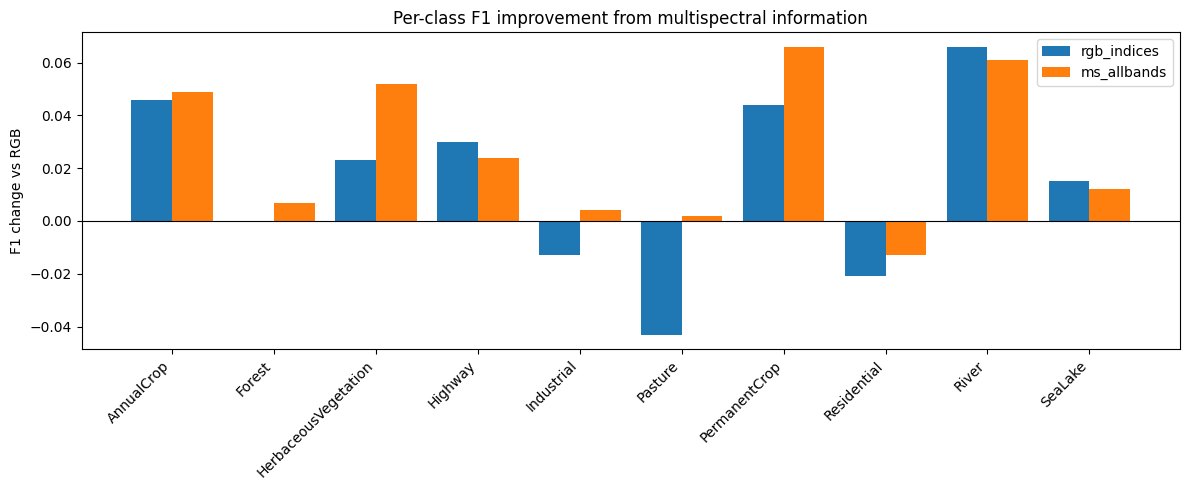

In [66]:
# Visualise per-class F1 deltas — the clearest single view of where MS helps
delta_cols = [c for c in per_class.columns if c.endswith("_Δf1")]
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(CLASS_NAMES))
w = 0.8 / len(delta_cols)
for i, col in enumerate(delta_cols):
    ax.bar(x + i * w, per_class[col], width=w, label=col.replace("_Δf1", ""))
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x + w * (len(delta_cols) - 1) / 2)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_ylabel("F1 change vs RGB")
ax.set_title("Per-class F1 improvement from multispectral information")
ax.legend()
plt.tight_layout()
plt.show()

In [67]:
# Persist artifacts so M4 reads identical results
for name, r in ms_results.items():
    torch.save(r["model"].state_dict(), ARTIFACTS / f"{name}.pt")

    pred_df = test_df[["patch_id", "class_label"]].copy()
    pred_df["true_idx"] = r["targets"]
    pred_df["pred_idx"] = r["preds"]
    pred_df["pred_label"] = [CLASS_NAMES[p] for p in r["preds"]]
    pred_df["correct"] = pred_df["true_idx"] == pred_df["pred_idx"]
    pred_df.to_csv(ARTIFACTS / f"{name}_test_predictions.csv", index=False)

    with open(ARTIFACTS / f"{name}_metrics.json", "w") as f:
        json.dump({
            "model": name,
            "in_channels": r["in_channels"],
            "bands": r["cfg"]["bands"],
            "indices": r["cfg"]["indices"],
            "test_accuracy": float(r["test_acc"]),
            "test_loss": float(r["test_loss"]),
            "per_class": {c: r["report"][c] for c in CLASS_NAMES},
            "macro_f1": r["report"]["macro avg"]["f1-score"],
            "weighted_f1": r["report"]["weighted avg"]["f1-score"],
            "mean": r["mean"].tolist(), "std": r["std"].tolist(),
            "epochs": EPOCHS, "batch_size": BATCH_SIZE, "lr": LR, "seed": RANDOM_SEED,
        }, f, indent=2)

summary.to_csv(ARTIFACTS / "comparison_summary.csv", index=False)
per_class.to_csv(ARTIFACTS / "per_class_deltas.csv", index=False)
print("Saved per-variant weights, predictions, metrics + comparison tables.")

Saved per-variant weights, predictions, metrics + comparison tables.


# Comparative Analysis

Previous approaches produced the models and raw
metrics; here we interpret them to answer the brief's central question — **what is the
value of multispectral information for land-use classification, and where does it come
from?**

This includes:

- Objective accuracy on the 80/20 split → **§1 overall, §2 per-class**
- Subjective assessment using sample results → **§5 sample viewer**
- Discussion of differences and conclusions → **§3 confusion shifts, §4 agreement,
     §6 interpretation, §7 conclusions**

All analysis reads from the saved artifacts (`*_metrics.json`, `*_test_predictions.csv`),
so it reflects the exact, reproducible results — and several cells **print the findings
in words** so the report narrative is generated from the data, not asserted.

In [68]:
from pathlib import Path
print(sorted(p.name for p in Path("artifacts").glob("*_metrics.json")))

['ms_allbands_metrics.json', 'rgb_baseline_metrics.json', 'rgb_indices_metrics.json', 'rgb_metrics.json']


In [69]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Reuses from earlier cells: CLASS_NAMES, ARTIFACTS, read_ms,
# B_RED, B_GREEN, B_BLUE, data_index.csv

MODELS = ["rgb_baseline", "rgb_indices", "ms_allbands"]

# Load metrics + per-patch predictions for every model
metrics, preds = {}, {}
for m in MODELS:
    with open(ARTIFACTS / f"{m}_metrics.json") as f:
        metrics[m] = json.load(f)
    preds[m] = pd.read_csv(ARTIFACTS / f"{m}_test_predictions.csv")

# Align all prediction frames on patch_id so per-patch comparison is exact
base = preds["rgb_baseline"][["patch_id", "class_label", "true_idx"]].copy()
for m in MODELS:
    base = base.merge(
        preds[m][["patch_id", "pred_idx", "correct"]].rename(
            columns={"pred_idx": f"{m}_pred", "correct": f"{m}_correct"}
        ),
        on="patch_id",
    )
print(f"Loaded {len(MODELS)} models, aligned on {len(base)} test patches.")
print("Models:", MODELS)

Loaded 3 models, aligned on 5400 test patches.
Models: ['rgb_baseline', 'rgb_indices', 'ms_allbands']


### Objective comparison — overall

Headline accuracy and macro-F1 for each configuration on the identical held-out test
set. Macro-F1 (unweighted class mean) matters here because EuroSAT is mildly imbalanced,
so it gives every class equal say regardless of size.

In [70]:
overall = pd.DataFrame([{
    "model": m,
    "channels": metrics[m]["in_channels"],
    "test_acc": metrics[m]["test_accuracy"],
    "macro_f1": metrics[m]["macro_f1"],
    "weighted_f1": metrics[m]["weighted_f1"],
} for m in MODELS])

rgb_acc = overall.loc[overall.model == "rgb_baseline", "test_acc"].iloc[0]
rgb_mf1 = overall.loc[overall.model == "rgb_baseline", "macro_f1"].iloc[0]
overall["acc_Δ_vs_rgb"] = overall["test_acc"] - rgb_acc
overall["mf1_Δ_vs_rgb"] = overall["macro_f1"] - rgb_mf1
overall = overall.round(4)
print(overall.to_string(index=False))

# --- Auto-generated finding (reads real numbers) ---
best = overall.loc[overall["macro_f1"].idxmax()]
print("\n--- FINDING ---")
print(f"Best model by macro-F1: {best.model} "
      f"({best.macro_f1:.3f} macro-F1, {best.test_acc:.3f} acc).")
for m in ["rgb_indices", "ms_allbands"]:
    row = overall[overall.model == m].iloc[0]
    direction = "above" if row["acc_Δ_vs_rgb"] >= 0 else "below"
    print(f"{m}: {abs(row['acc_Δ_vs_rgb'])*100:.2f} pts {direction} RGB on accuracy, "
          f"{row['mf1_Δ_vs_rgb']:+.3f} macro-F1.")

       model  channels  test_acc  macro_f1  weighted_f1  acc_Δ_vs_rgb  mf1_Δ_vs_rgb
rgb_baseline         3    0.9646    0.9631       0.9645        0.0000        0.0000
 rgb_indices         6    0.9591    0.9571       0.9589       -0.0056       -0.0060
 ms_allbands        12    0.9696    0.9687       0.9696        0.0050        0.0057

--- FINDING ---
Best model by macro-F1: ms_allbands (0.969 macro-F1, 0.970 acc).
rgb_indices: 0.56 pts below RGB on accuracy, -0.006 macro-F1.
ms_allbands: 0.50 pts above RGB on accuracy, +0.006 macro-F1.


### Objective comparison — per class

Overall accuracy hides the multispectral story because RGB is already strong. The
per-class F1 change is where the value of spectral information actually shows up. The
hypothesis from M2/M3: gains concentrate in the **vegetation-type classes** (AnnualCrop,
PermanentCrop, Pasture, HerbaceousVegetation), which are spectrally distinct but
visually similar in RGB.

               class  rgb_baseline  rgb_indices  ms_allbands  rgb_indices_Δ  ms_allbands_Δ
          AnnualCrop         0.952        0.950        0.953         -0.002          0.001
              Forest         0.985        0.982        0.989         -0.003          0.004
HerbaceousVegetation         0.958        0.943        0.971         -0.015          0.013
             Highway         0.957        0.971        0.964          0.014          0.007
          Industrial         0.972        0.953        0.971         -0.018         -0.001
             Pasture         0.938        0.907        0.952         -0.030          0.015
       PermanentCrop         0.926        0.924        0.946         -0.002          0.020
         Residential         0.979        0.961        0.969         -0.018         -0.010
               River         0.972        0.982        0.977          0.010          0.005
             SeaLake         0.992        0.997        0.993          0.005          0.002

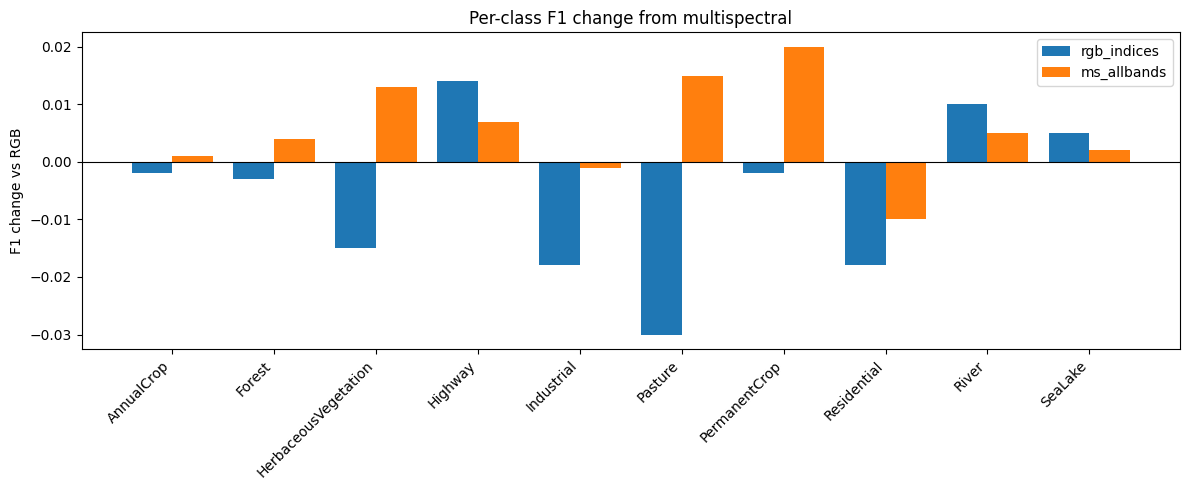

--- FINDING ---

rgb_indices:
  most improved: Highway (+0.014), River (+0.010), SeaLake (+0.005)
  most regressed: Residential (-0.018), Pasture (-0.030)

ms_allbands:
  most improved: PermanentCrop (+0.020), Pasture (+0.015), HerbaceousVegetation (+0.013)
  most regressed: Industrial (-0.001), Residential (-0.010)


In [71]:
per_class = pd.DataFrame({"class": CLASS_NAMES})
for m in MODELS:
    per_class[m] = [metrics[m]["per_class"][c]["f1-score"] for c in CLASS_NAMES]
for m in ["rgb_indices", "ms_allbands"]:
    per_class[f"{m}_Δ"] = (per_class[m] - per_class["rgb_baseline"]).round(3)
print(per_class.round(3).to_string(index=False))

# Bar chart of F1 deltas
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(CLASS_NAMES))
delta_cols = [f"{m}_Δ" for m in ["rgb_indices", "ms_allbands"]]
w = 0.8 / len(delta_cols)
for i, col in enumerate(delta_cols):
    ax.bar(x + i * w, per_class[col], width=w, label=col.replace("_Δ", ""))
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x + w * (len(delta_cols) - 1) / 2)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_ylabel("F1 change vs RGB"); ax.set_title("Per-class F1 change from multispectral")
ax.legend(); plt.tight_layout(); plt.show()

# --- Auto-generated finding ---
print("--- FINDING ---")
for m in ["rgb_indices", "ms_allbands"]:
    s = per_class[["class", f"{m}_Δ"]].sort_values(f"{m}_Δ", ascending=False)
    gained = s.head(3).values.tolist()
    lost = s.tail(2).values.tolist()
    print(f"\n{m}:")
    print("  most improved:", ", ".join(f"{c} ({d:+.3f})" for c, d in gained))
    print("  most regressed:", ", ".join(f"{c} ({d:+.3f})" for c, d in lost))

### Confusion shifts 

Compare the confusion matrices of RGB and
the best multispectral model, and look at the **difference**. We use the best model by
macro-F1 (chosen programmatically).



Best multispectral model: ms_allbands



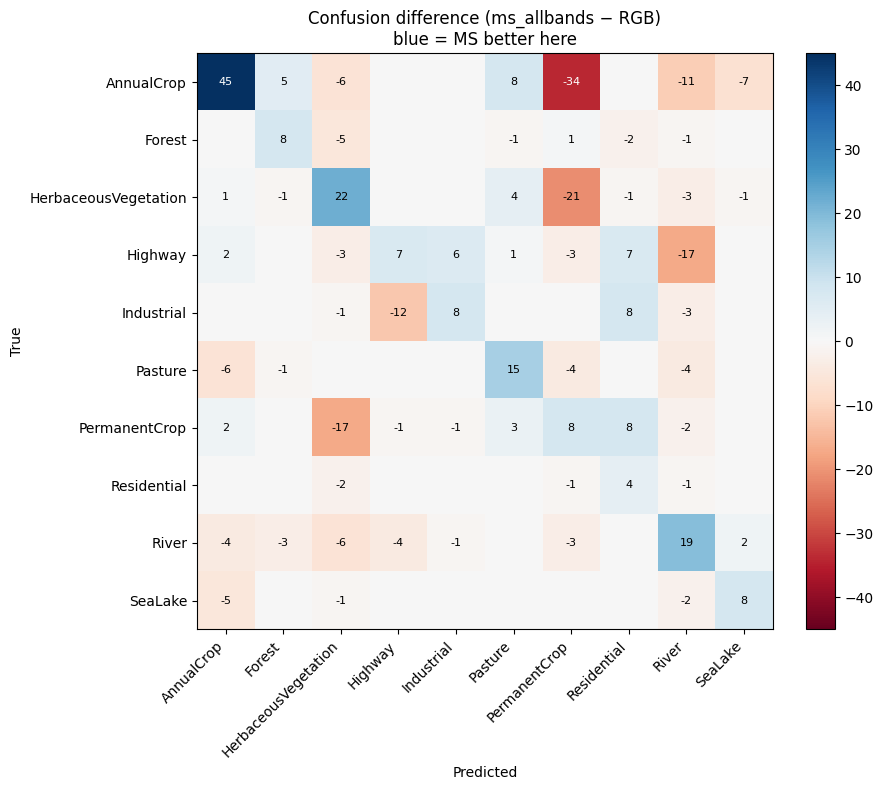

In [72]:
best_ms = overall[overall.model != "rgb_baseline"].sort_values(
    "macro_f1", ascending=False
).iloc[0]["model"]
print(f"Best multispectral model: {best_ms}\n")

cm_rgb = confusion_matrix(base["true_idx"], base["rgb_baseline_pred"])
cm_ms  = confusion_matrix(base["true_idx"], base[f"{best_ms}_pred"])
cm_diff = cm_ms - cm_rgb

vmax = np.abs(cm_diff).max()
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm_diff, cmap="RdBu", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(CLASS_NAMES))); ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right"); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion difference ({best_ms} − RGB)\nblue = MS better here")
for r in range(len(CLASS_NAMES)):
    for c in range(len(CLASS_NAMES)):
        if cm_diff[r, c] != 0:
            ax.text(c, r, cm_diff[r, c], ha="center", va="center", fontsize=8,
                    color="white" if abs(cm_diff[r, c]) > vmax * 0.6 else "black")
fig.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()

In [73]:
# Auto-extract the specific confusions MS reduced and introduced most
off = []
for r in range(len(CLASS_NAMES)):
    for c in range(len(CLASS_NAMES)):
        if r != c and cm_diff[r, c] != 0:
            off.append({
                "true": CLASS_NAMES[r], "predicted": CLASS_NAMES[c],
                "rgb_errors": cm_rgb[r, c], "ms_errors": cm_ms[r, c],
                "change": cm_diff[r, c],
            })
off = pd.DataFrame(off)

print("--- Confusions MS fixed most (largest reductions) ---")
print(off.sort_values("change").head(6).to_string(index=False))
print("\n--- Confusions MS made worse (if any) ---")
worse = off[off.change > 0].sort_values("change", ascending=False)
print(worse.head(6).to_string(index=False) if len(worse) else "None — MS introduced no new confusions.")

--- Confusions MS fixed most (largest reductions) ---
                true            predicted  rgb_errors  ms_errors  change
          AnnualCrop        PermanentCrop          52         18     -34
HerbaceousVegetation        PermanentCrop          28          7     -21
             Highway                River          22          5     -17
       PermanentCrop HerbaceousVegetation          23          6     -17
          Industrial              Highway          14          2     -12
          AnnualCrop                River          11          0     -11

--- Confusions MS made worse (if any) ---
         true   predicted  rgb_errors  ms_errors  change
   AnnualCrop     Pasture           3         11       8
   Industrial Residential          10         18       8
PermanentCrop Residential           0          8       8
      Highway Residential           1          8       7
      Highway  Industrial           1          7       6
   AnnualCrop      Forest           0          5  

### Do RGB and MS fail on the same patches?

Beyond aggregate counts: on a per-patch basis, where do the two models agree and
disagree? This tells us whether multispectral information is *fixing RGB's specific
failures* (complementary) or just shifting errors around. It also reveals an
**irreducible-error floor** — patches both models get wrong — which bounds what any
single model can achieve here.

In [74]:
both_correct = (base["rgb_baseline_correct"] & base[f"{best_ms}_correct"]).sum()
both_wrong   = (~base["rgb_baseline_correct"] & ~base[f"{best_ms}_correct"]).sum()
ms_fixed     = (~base["rgb_baseline_correct"] & base[f"{best_ms}_correct"]).sum()
ms_broke     = (base["rgb_baseline_correct"] & ~base[f"{best_ms}_correct"]).sum()
n = len(base)

agree = pd.DataFrame({
    "outcome": ["both correct", "both wrong", "MS fixed RGB", "MS broke RGB"],
    "count": [both_correct, both_wrong, ms_fixed, ms_broke],
})
agree["pct"] = (agree["count"] / n * 100).round(2)
print(agree.to_string(index=False))

print("\n--- FINDING ---")
print(f"Irreducible floor (both wrong): {both_wrong} patches ({both_wrong/n*100:.1f}%).")
net = ms_fixed - ms_broke
print(f"Net patches rescued by multispectral: {ms_fixed} fixed − {ms_broke} broke "
      f"= {net:+d} ({net/n*100:+.2f} pts).")
if ms_fixed > 0 and ms_broke > 0:
    print("RGB and MS fail partly on DIFFERENT patches → an ensemble could plausibly "
          "beat either alone (candidate for the extension).")

     outcome  count   pct
both correct   5000 92.59
  both wrong     72  1.33
MS fixed RGB    236  4.37
MS broke RGB     92  1.70

--- FINDING ---
Irreducible floor (both wrong): 72 patches (1.3%).
Net patches rescued by multispectral: 236 fixed − 92 broke = +144 (+2.67 pts).
RGB and MS fail partly on DIFFERENT patches → an ensemble could plausibly beat either alone (candidate for the extension).


### Subjective assessment — sample results

The brief explicitly asks for a subjective evaluation using sample results. The most
informative view is the set of patches **multispectral got right that RGB got wrong** —
these are the cases where spectral information made the difference. For honesty we also
show the reverse (MS broke RGB), so the discussion isn't cherry-picked.

Patches are shown as true-colour composites (what RGB "sees"), with true and predicted
labels for both models.

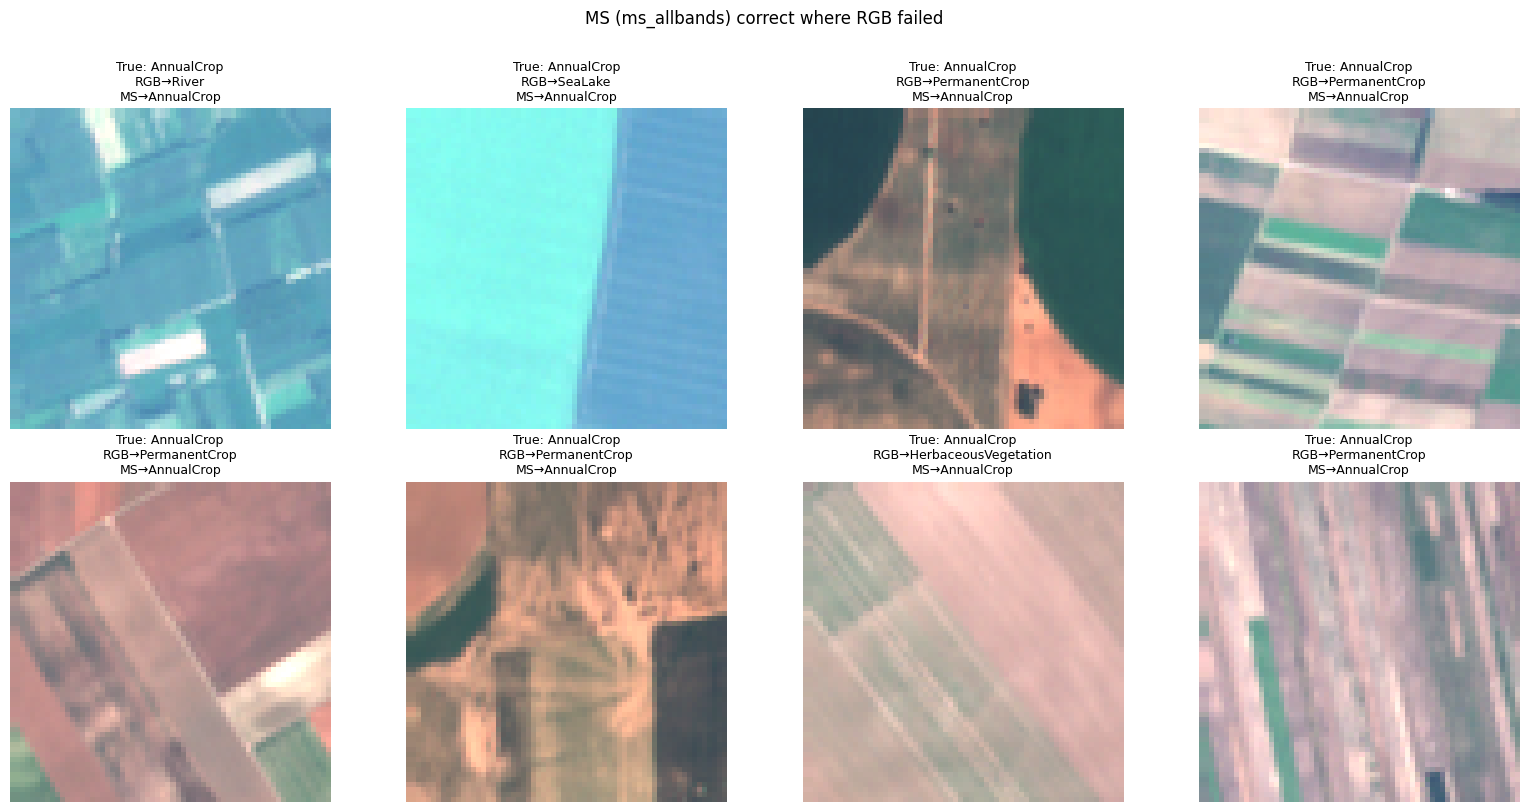

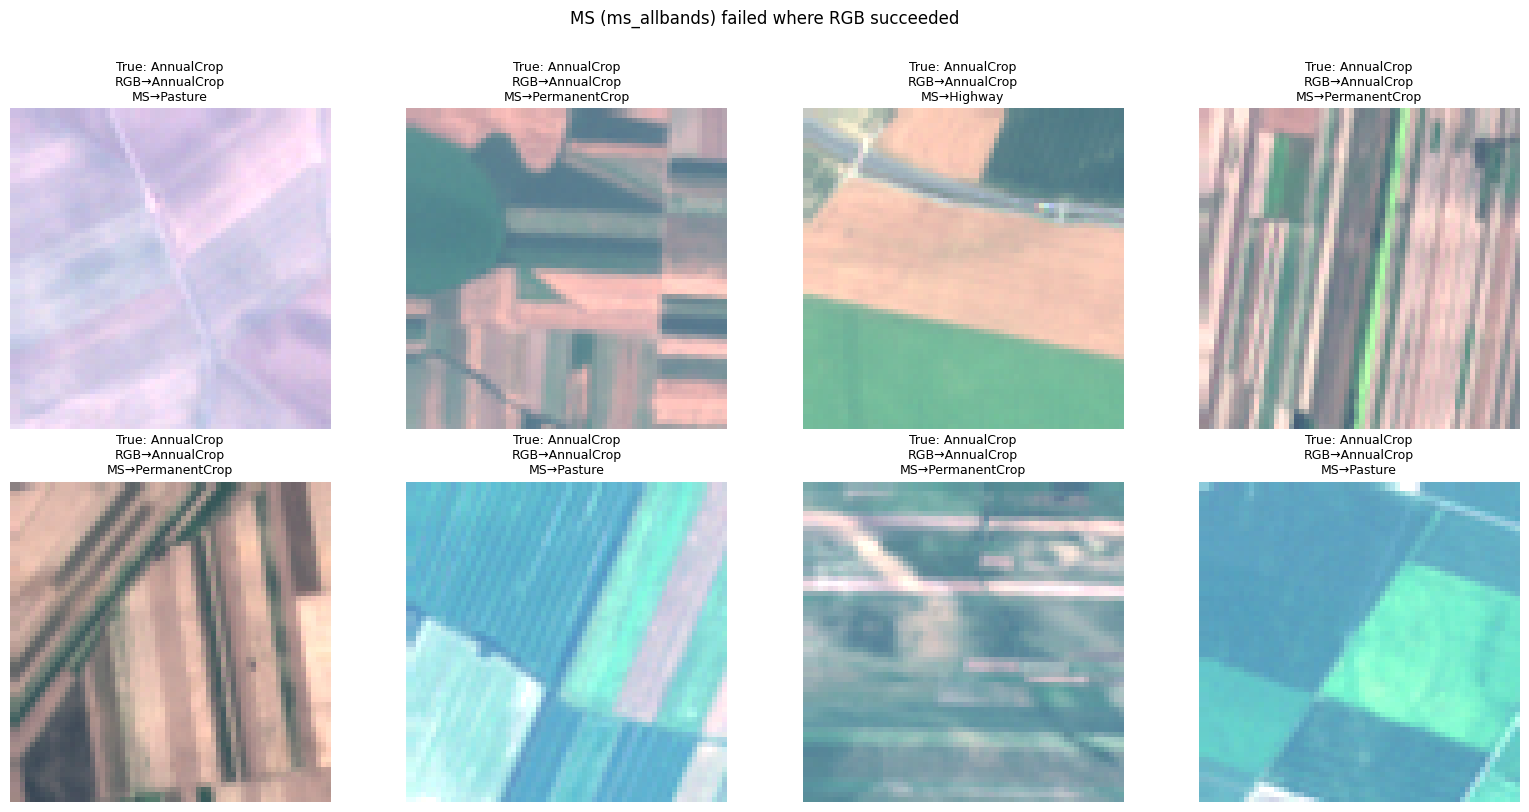

In [75]:
full_index = pd.read_csv("data_index.csv").set_index("patch_id")

def show_disagreements(kind="ms_fixed", n=8):
    """kind: 'ms_fixed' (RGB wrong, MS right) or 'ms_broke' (RGB right, MS wrong)."""
    if kind == "ms_fixed":
        mask = ~base["rgb_baseline_correct"] & base[f"{best_ms}_correct"]
        title = f"MS ({best_ms}) correct where RGB failed"
    else:
        mask = base["rgb_baseline_correct"] & ~base[f"{best_ms}_correct"]
        title = f"MS ({best_ms}) failed where RGB succeeded"

    sub = base[mask].head(n)
    if len(sub) == 0:
        print(f"No '{kind}' cases."); return

    cols = 4
    rows = (len(sub) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, sub.iterrows()):
        raw = read_ms(full_index.loc[row.patch_id, "ms_path"])
        tc = np.dstack([raw[B_RED], raw[B_GREEN], raw[B_BLUE]])
        tc = np.clip(tc / np.percentile(tc, 99), 0, 1)
        ax.imshow(tc)
        true_c = CLASS_NAMES[row.true_idx]
        rgb_c = CLASS_NAMES[row.rgb_baseline_pred]
        ms_c = CLASS_NAMES[row[f"{best_ms}_pred"]]
        ax.set_title(f"True: {true_c}\nRGB→{rgb_c}\nMS→{ms_c}", fontsize=9)
        ax.axis("off")
    for ax in axes[len(sub):]:
        ax.axis("off")
    plt.suptitle(title, y=1.01); plt.tight_layout(); plt.show()

show_disagreements("ms_fixed", n=8)
show_disagreements("ms_broke", n=8)

### Physical interpretation — why the gains land where they do

The mechanism behind the numbers above (the science is independent of the exact deltas):

- **Vegetation classes (AnnualCrop, PermanentCrop, Pasture, HerbaceousVegetation)** are
  the hardest to separate in RGB because they are all simply "green" to the visible
  bands. They differ in canopy structure, chlorophyll content, and moisture — properties
  that show up in **NIR (B08)** and the **red-edge bands (B05–B07)**, not in visible
  colour. NDVI packages the NIR-vs-red contrast into one discriminative feature. So if
  the per-class gains (§2) and the fixed confusions (§3) concentrate among these classes,
  that is the expected signature of red-edge/NIR information doing the work.

- **Water classes (River, Sea/Lake)** are already fairly separable in RGB (they are
  blue/dark), so NDWI tends to *sharpen* boundaries rather than transform performance —
  expect smaller gains here.

- **Built-up classes (Industrial, Residential)** carry a distinctive **SWIR (B11/B12)**
  signature (dry, man-made materials) captured by NDBI, which can resolve
  Industrial↔Residential and Highway confusions.

The `rgb_indices` vs `ms_allbands` contrast then tells us *how* the information is best
delivered: if three engineered indices roughly match all twelve raw bands, the useful
signal is low-dimensional and interpretable; if all-bands wins clearly, there is extra
discriminative structure (likely red-edge crop signatures) that hand-crafted indices miss.

In [77]:
# Auto-generated narrative paragraph — paste straight into the report, numbers are real
veg = ["AnnualCrop", "PermanentCrop", "Pasture", "HerbaceousVegetation"]
veg_gain = per_class[per_class["class"].isin(veg)][f"{best_ms}_Δ"].mean()
nonveg_gain = per_class[~per_class["class"].isin(veg)][f"{best_ms}_Δ"].mean()

print("=== AUTO-GENERATED SUMMARY (real numbers) ===\n")
print(f"Best multispectral model: {best_ms} "
      f"({metrics[best_ms]['test_accuracy']:.3f} acc vs {rgb_acc:.3f} RGB, "
      f"{metrics[best_ms]['macro_f1']:.3f} vs {rgb_mf1:.3f} macro-F1).")
print(f"\nMean F1 change, vegetation classes:   {veg_gain:+.3f}")
print(f"Mean F1 change, non-vegetation classes: {nonveg_gain:+.3f}")
verdict = ("concentrated in vegetation classes, consistent with NIR/red-edge information"
           if veg_gain > nonveg_gain else
           "spread across classes rather than vegetation-specific")
print(f"\nInterpretation: multispectral gains are {verdict}.")
print(f"Net patches rescued: {ms_fixed - ms_broke:+d} of {n} test patches.")
print(f"Irreducible (both-wrong) floor: {both_wrong/n*100:.1f}%.")

=== AUTO-GENERATED SUMMARY (real numbers) ===

Best multispectral model: ms_allbands (0.970 acc vs 0.965 RGB, 0.969 vs 0.963 macro-F1).

Mean F1 change, vegetation classes:   +0.012
Mean F1 change, non-vegetation classes: +0.001

Interpretation: multispectral gains are concentrated in vegetation classes, consistent with NIR/red-edge information.
Net patches rescued: +144 of 5400 test patches.
Irreducible (both-wrong) floor: 1.3%.
